# 실험 B — 활성화 함수 비교: ReLU vs LeakyReLU vs Sigmoid

**컴퓨터비전 과제 / TensorFlow (Google Colab)**

---

## 1) 실험 목표
- **ReLU, LeakyReLU, Sigmoid** 세 활성화 함수가 학습에 미치는 영향을 분석한다.
- 작은 weight 초기화로 **Dead ReLU 현상을 의도적으로 유도**하고, 발생 비율을 정량 측정한다.
- **LeakyReLU가 Dead ReLU를 얼마나 완화**하는지 확인한다.
- **Sigmoid의 Vanishing Gradient**가 어느 층에서 발생하는지 gradient flow로 시각화한다.

## 2) 데이터셋 — make_moons (scikit-learn)
- 2D 비선형 이진 분류 문제. 초승달 두 개가 맞물린 형태로, 결정 경계 시각화에 유리하다.
- 입력이 2차원이라 학습된 결정 경계를 평면에 직접 그릴 수 있다.

## 3) 실험 조건 (통제 변수)
| 항목 | 설정 |
|---|---|
| 네트워크 | MLP: 2 → 64 → 64 → 32 → 2 (은닉 3층) |
| 손실 함수 | CrossEntropy (from_logits=True) — 세 실험 동일 |
| Optimizer | Adam (lr = 0.01) — 세 실험 동일 |
| Epoch | 200 |
| Batch size | 32 |
| **가중치 초기화** | **RandomNormal(std=0.01)** — 작게 설정해 Dead ReLU 유도 |
| **변경 변수** | **활성화 함수만** (ReLU / LeakyReLU / Sigmoid) |

> **왜 작은 초기화로 Dead ReLU가 유도되는가**
> weight가 매우 작으면 일부 뉴런의 입력 가중합이 음수 영역에 갇히기 쉽다. ReLU는 음수 입력을 모두 0으로 만들고 그 구간의 gradient도 0이므로, 한번 음수 영역에 들어간 뉴런은 가중치가 갱신되지 않아 영구히 죽는다(Dead ReLU). LeakyReLU는 음수 구간에도 작은 기울기를 주어 이 문제를 완화한다.


## 4) 환경 설정 및 라이브러리 임포트

In [16]:
# 라이브러리 임포트
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

# 재현성: 난수 시드 고정
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


## 5) 데이터 로드 및 전처리

`make_moons`로 2D 초승달 데이터를 생성한다. `noise=0.2`로 적당한 잡음을 주어
선형 분리가 불가능한 비선형 문제로 만든다.

In [17]:
# make_moons 데이터 생성
X, y = make_moons(n_samples=2000, noise=0.2, random_state=SEED)
X = X.astype("float32")

NUM_CLASSES = 2

# train/test 분할 (stratify로 클래스 비율 유지)
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y)

# 라벨 one-hot 인코딩
y_train_oh = tf.keras.utils.to_categorical(y_train, NUM_CLASSES)
y_test_oh  = tf.keras.utils.to_categorical(y_test,  NUM_CLASSES)

print("train:", x_train.shape, " test:", x_test.shape)


train: (1600, 2)  test: (400, 2)


### 데이터 분포 시각화

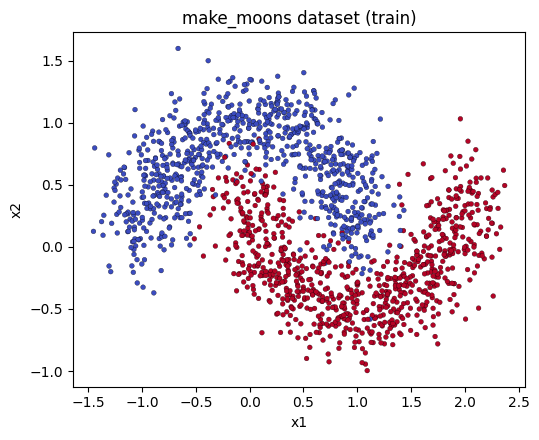

In [18]:
# 학습 데이터의 2D 분포 확인
plt.figure(figsize=(5.5, 4.5))
plt.scatter(x_train[:, 0], x_train[:, 1], c=y_train,
            cmap="coolwarm", s=12, edgecolor="k", linewidth=0.2)
plt.title("make_moons dataset (train)")
plt.xlabel("x1"); plt.ylabel("x2")
plt.tight_layout()
plt.show()


## 6) 하이퍼파라미터 및 모델 정의

세 실험에서 **활성화 함수만 다르고 나머지는 모두 동일**한 모델을 사용한다.
가중치 초기화는 `RandomNormal(std=0.01)`로 작게 설정하여 Dead ReLU를 유도한다.

`build_model(activation)` 함수는 활성화 함수 이름을 받아 해당 모델을 만든다.
은닉층마다 Dense + 활성화를 분리해 쌓는 이유는, 이후 **활성화 레이어의 출력을 따로 추출**하여
Dead 뉴런 비율과 활성화 분포를 분석하기 위함이다.

In [19]:
# 하이퍼파라미터
# 과제 안내사항의 에폭 가이드 200 ~ 500
EPOCHS        = 200
BATCH_SIZE    = 32
LEARNING_RATE = 0.01
HIDDEN_UNITS  = [64, 64, 32]   # 은닉 3층

# 작은 weight 초기화 (Dead ReLU 유도용)
def small_init():
    return tf.keras.initializers.RandomNormal(mean=0.0, stddev=0.01, seed=SEED)

# 모델 정의 함수
def build_model(activation):
    # activation: 'relu' | 'leaky_relu' | 'sigmoid'
    # Dense 와 활성화 레이어를 분리해 쌓는다 (활성화 출력 추출용).
    tf.random.set_seed(SEED)

    def act_layer(idx):
        # idx: 은닉층 번호 -> 레이어 이름을 고유하게 만든다
        nm = f"act{idx}_{activation}"
        if activation == "relu":
            return tf.keras.layers.ReLU(name=nm)
        elif activation == "leaky_relu":
            return tf.keras.layers.LeakyReLU(negative_slope=0.01, name=nm)
        elif activation == "sigmoid":
            return tf.keras.layers.Activation("sigmoid", name=nm)
        else:
            raise ValueError("activation must be relu/leaky_relu/sigmoid")

    layers = [tf.keras.layers.Input(shape=(2,))]
    for i, units in enumerate(HIDDEN_UNITS):
        layers.append(tf.keras.layers.Dense(
            units, kernel_initializer=small_init(), name=f"dense{i+1}"))
        layers.append(act_layer(i + 1))
    layers.append(tf.keras.layers.Dense(NUM_CLASSES, activation=None,
                                        name="logits"))
    return tf.keras.Sequential(layers)

build_model("relu").summary()


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense1 (Dense)                  │ (None, 64)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act1_relu (ReLU)                │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2 (Dense)                  │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act2_relu (ReLU)                │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense3 (Dense)                  │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act3_relu (ReLU)                │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ logits (Dense)                  │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,498 (25.38 KB)

 Trainable params: 6,498 (25.38 KB)

 Non-trainable params: 0 (0.00 B)

## 7) 수동 학습 루프 + 분석용 측정 함수 정의

학습 루프는 실험 A와 동일하게 `for epoch` + `tf.GradientTape` 형태로 작성한다.
추가로 실험 B 분석을 위한 두 측정 함수를 정의한다.

1. **`get_activations`** : 입력을 넣어 각 활성화 레이어의 출력값을 추출한다.
   Dead 뉴런 비율 계산과 활성화 분포 히스토그램에 사용한다.
2. **`layer_grad_norms`** : 각 Dense 레이어 kernel의 gradient norm을 측정한다.
   입력층→출력층 방향으로 gradient가 소멸하는지(vanishing) 확인하는 데 사용한다.

In [20]:
# 다중 클래스 분류를 위한 Cross Entropy 손실 함수 정의 (모델 출력이 확률이 아닌 원시 값(logits)임을 명시)
cce_loss_fn = tf.keras.losses.CategoricalCrossentropy(from_logits=True)


def get_activations(model, X):
    # 각 활성화 레이어의 출력을 순서대로 반환한다.
    acts, names = [], []
    x = tf.convert_to_tensor(X)
    for layer in model.layers:
        x = layer(x, training=False)
        cls = layer.__class__.__name__
        if cls in ("ReLU", "LeakyReLU", "Activation"):
            acts.append(x.numpy())
            names.append(layer.name)
    return names, acts


def dead_neuron_ratio(model, X, eps=1e-6):
    # 모든 입력 샘플에 대해 출력이 0인 뉴런의 비율(레이어별).
    # ReLU 계열에서 Dead 뉴런을 측정. (Sigmoid는 0 출력이 없어 0에 가까움)
    names, acts = get_activations(model, X)
    ratios = []
    for a in acts:
        dead = np.mean(np.all(np.abs(a) < eps, axis=0))
        ratios.append(dead)
    return names, ratios


def layer_grad_norms(model, X, y_oh):
    # 각 Dense 레이어 kernel의 gradient L2 norm (입력층 -> 출력층 순).
    with tf.GradientTape() as tape:
        logits = model(X, training=True)
        loss = cce_loss_fn(y_oh, logits)

    # 한 번에 모든 학습 가능한 변수에 대한 기울기 계산
    grads = tape.gradient(loss, model.trainable_variables)

    norms, names = [], []

    # 모델의 레이어를 순회하며 직접 정확한 레이어 이름을 추출.
    for layer in model.layers:
        if layer.trainable_variables:
            for v in layer.trainable_variables:
                if "kernel" in v.name:
                    # model.trainable_variables 리스트에서 현재 가중치(v)의 인덱스를 찾아
                    # 대응되는 기울기(g)를 가져옵니다.
                    idx = model.trainable_variables.index(v)
                    g = grads[idx]

                    norms.append(float(tf.norm(g)))
                    names.append(layer.name)

    return names, norms

def train_model(activation, epochs=EPOCHS, lr=LEARNING_RATE, verbose=True):
    # 활성화 함수별(ReLU, LeakyReLU, Sigmoid)로 성능 차이와 Dead ReLU 발생 양상을 추적합니다.

    model = build_model(activation) # 활성화 함수를 인자로 받아 모델 생성
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)

    # tf.data.Dataset을 활용해 훈련 데이터를 셔플링하고 미니배치로 분할
    train_ds = (tf.data.Dataset
                .from_tensor_slices((x_train, y_train_oh))
                .shuffle(2000, seed=SEED)
                .batch(BATCH_SIZE))

    # 에폭별 성능 및 분석 지표를 저장할 딕셔너리
    history = {"train_loss": [], "train_acc": [],
               "test_loss": [],  "test_acc": [], "dead_ratio": []}

    y_train_int = tf.constant(y_train, dtype=tf.int64)
    y_test_int  = tf.constant(y_test,  dtype=tf.int64)

    for epoch in range(epochs):
        # 1. 미니배치 단위 학습 (Forward & Backward Pass)
        for xb, yb in train_ds:
            with tf.GradientTape() as tape:
                logits = model(xb, training=True)
                loss   = cce_loss_fn(yb, logits)

            # 역전파(Backpropagation) 수행 및 가중치 업데이트
            grads = tape.gradient(loss, model.trainable_variables)
            optimizer.apply_gradients(zip(grads, model.trainable_variables))

        # 2. 에폭 종료 후 모델 평가 (추론 모드: training=False)
        tr_logits = model(x_train, training=False)
        te_logits = model(x_test,  training=False)

        tr_loss = cce_loss_fn(y_train_oh, tr_logits).numpy()
        te_loss = cce_loss_fn(y_test_oh,  te_logits).numpy()

        tr_acc = np.mean(np.argmax(tr_logits, axis=1) == y_train)
        te_acc = np.mean(np.argmax(te_logits, axis=1) == y_test)

        # 3. 전체 데이터셋 기준 평균 Dead 뉴런 비율 측정 및 기록
        _, ratios = dead_neuron_ratio(model, x_train)

        history["train_loss"].append(tr_loss)
        history["test_loss"].append(te_loss)
        history["train_acc"].append(tr_acc)
        history["test_acc"].append(te_acc)
        history["dead_ratio"].append(float(np.mean(ratios))) # 모든 층의 Dead 비율 평균값 저장

        # 4. 10 에폭마다 진행 상황 출력 (간소화)
        if verbose and (epoch+1) % 10 == 0:
            print(f"[{activation:11s}] epoch {epoch+1:3d}/{epochs} | "
                  f"test_acc={te_acc:.4f} dead_ratio={np.mean(ratios):.3f}")

    return model, history


## 8) 실험 실행 — 세 활성화 함수 학습

동일 구조·동일 손실·동일 optimizer에서 **활성화 함수만 교체**하여 세 번 학습한다.

In [21]:
results = {}
for act in ["relu", "leaky_relu", "sigmoid"]:
    print("=" * 58)
    print(f"활성화 함수: {act}")
    print("=" * 58)
    model, hist = train_model(act)
    results[act] = {"model": model, "hist": hist}
    print()

print("학습 완료.")


활성화 함수: relu
[relu       ] epoch  10/200 | test_acc=0.9425 dead_ratio=0.365
[relu       ] epoch  20/200 | test_acc=0.9600 dead_ratio=0.365
[relu       ] epoch  30/200 | test_acc=0.9600 dead_ratio=0.380
[relu       ] epoch  40/200 | test_acc=0.9550 dead_ratio=0.375
[relu       ] epoch  50/200 | test_acc=0.9550 dead_ratio=0.391
[relu       ] epoch  60/200 | test_acc=0.9600 dead_ratio=0.406
[relu       ] epoch  70/200 | test_acc=0.9550 dead_ratio=0.406
[relu       ] epoch  80/200 | test_acc=0.9550 dead_ratio=0.411
[relu       ] epoch  90/200 | test_acc=0.9575 dead_ratio=0.401
[relu       ] epoch 100/200 | test_acc=0.9500 dead_ratio=0.438
[relu       ] epoch 110/200 | test_acc=0.9550 dead_ratio=0.438
[relu       ] epoch 120/200 | test_acc=0.9600 dead_ratio=0.411
[relu       ] epoch 130/200 | test_acc=0.9600 dead_ratio=0.406
[relu       ] epoch 140/200 | test_acc=0.9675 dead_ratio=0.385
[relu       ] epoch 150/200 | test_acc=0.9600 dead_ratio=0.385
[relu       ] epoch 160/200 | test_acc=0.9

## 9) 그래프 및 시각화 결과

### 9-1) Loss / Accuracy vs Epoch
세 활성화 함수의 학습 곡선을 한 그래프에서 비교한다.

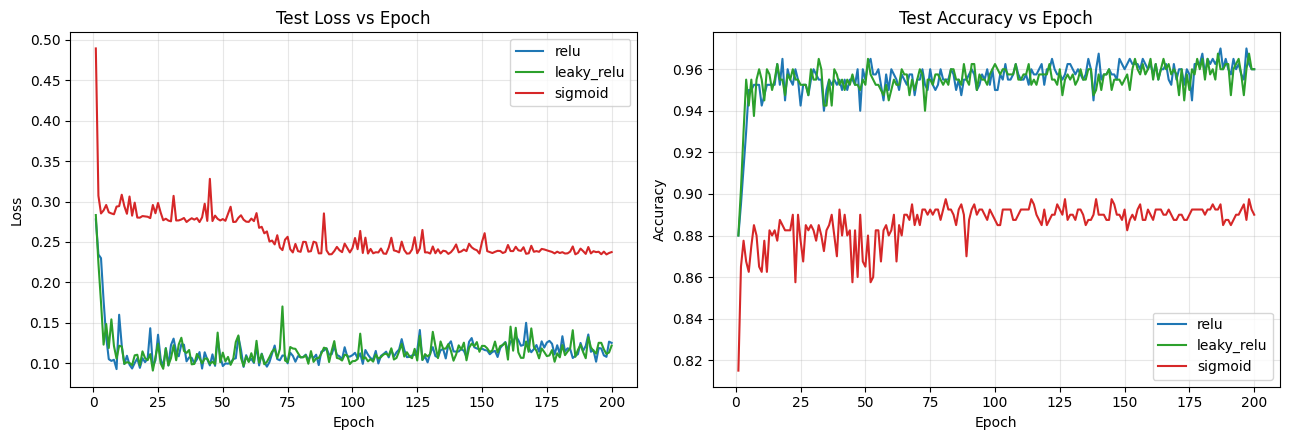

In [22]:
ep = range(1, EPOCHS + 1)
colors = {"relu": "#1f77b4", "leaky_relu": "#2ca02c", "sigmoid": "#d62728"}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for act in results:
    h = results[act]["hist"]
    axes[0].plot(ep, h["test_loss"], color=colors[act], label=act)
    axes[1].plot(ep, h["test_acc"], color=colors[act], label=act)
axes[0].set_title("Test Loss vs Epoch")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].set_title("Test Accuracy vs Epoch")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()


### 9-2) Dead 뉴런 비율 변화 (Dead ReLU vs LeakyReLU)
학습이 진행되는 동안 평균 Dead 뉴런 비율이 어떻게 변하는지 추적한다.
ReLU는 Dead 뉴런이 상당 비율 발생하는 반면, LeakyReLU와 Sigmoid는 0에 가깝게 유지된다.

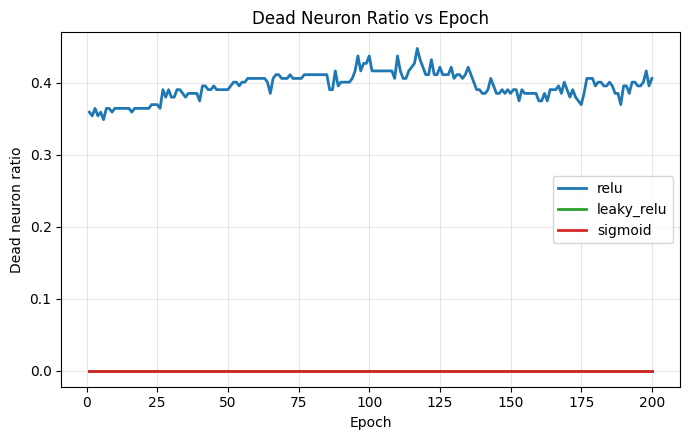

relu        layer-wise dead ratio: act1_relu=0.34, act2_relu=0.44, act3_relu=0.44
leaky_relu  layer-wise dead ratio: act1_leaky_relu=0.00, act2_leaky_relu=0.00, act3_leaky_relu=0.00
sigmoid     layer-wise dead ratio: act1_sigmoid=0.00, act2_sigmoid=0.00, act3_sigmoid=0.00


In [23]:
plt.figure(figsize=(7, 4.5))
for act in results:
    h = results[act]["hist"]
    plt.plot(ep, h["dead_ratio"], color=colors[act], label=act, linewidth=2)
plt.title("Dead Neuron Ratio vs Epoch")
plt.xlabel("Epoch"); plt.ylabel("Dead neuron ratio")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 학습 종료 시점의 레이어별 Dead 비율 출력
for act in results:
    names, ratios = dead_neuron_ratio(results[act]["model"], x_train)
    print(f"{act:11s} layer-wise dead ratio: "
          + ", ".join(f"{n}={r:.2f}" for n, r in zip(names, ratios)))


### 9-3) Dead 뉴런 히트맵

두 가지 관점으로 Dead 뉴런을 시각화한다.

**(A) 레이어별 Dead 뉴런 비율 요약 히트맵** — 행은 활성화 함수, 열은 은닉층이며
각 칸의 색과 숫자가 그 레이어의 dead 뉴런 비율(%)이다. 어느 활성화 함수의 어느 레이어가
얼마나 죽었는지 한눈에 비교할 수 있다. ReLU 행에 진한 칸이, LeakyReLU 행에 옅은 칸이
나타나면 LeakyReLU의 완화 효과가 레이어 단위로 드러난다.

**(B) 뉴런 단위 격자 히트맵** — 한 레이어의 뉴런들을 격자로 펼쳐 Dead(1)/Alive(0)를
색으로 표시한다. 죽은 뉴런이 레이어 안에서 얼마나/어디에 분포하는지 상세히 확인할 수 있다.


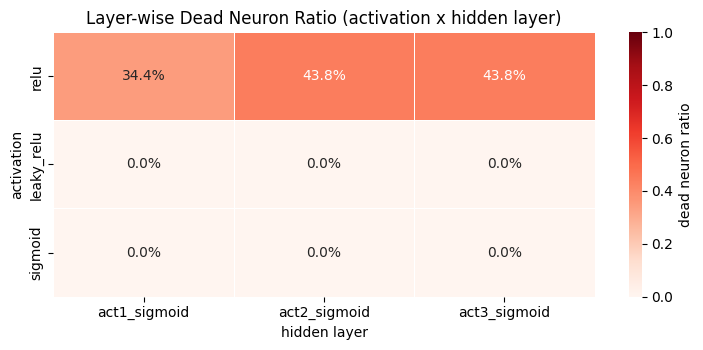

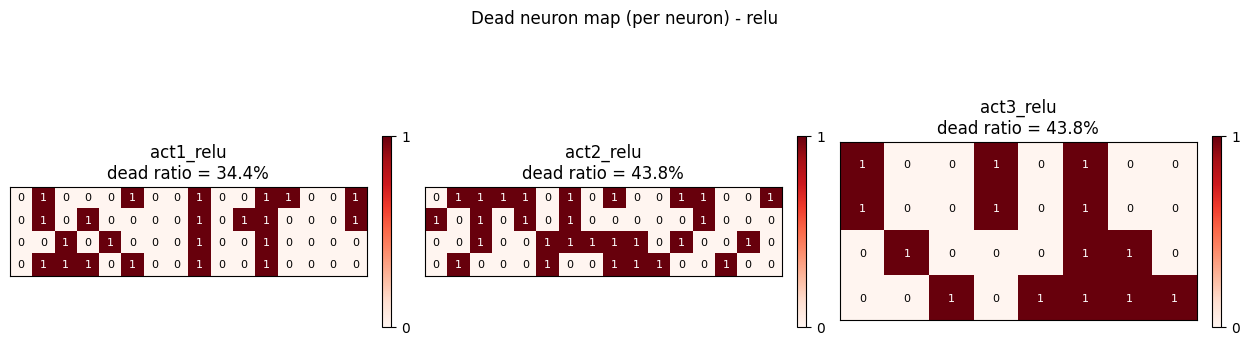

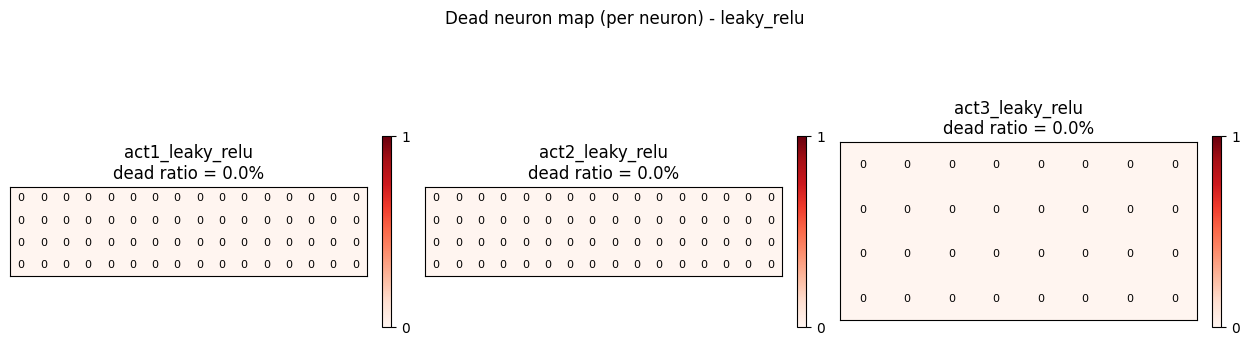

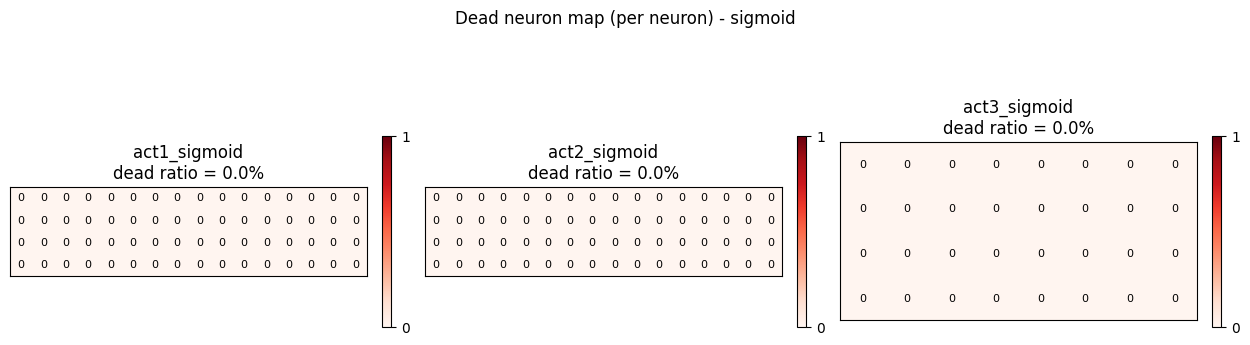

In [24]:
# 9-3) Dead 뉴런 히트맵
# 과제: "Dead ReLU가 발생한 neuron 비율 -> 히트맵 시각화"

# (A) 레이어별 Dead 뉴런 비율 요약 히트맵
#  - 행: 활성화 함수, 열: 은닉층 -> 칸 색/숫자 = 해당 레이어의 dead 비율(%)
#  - 어느 활성화 함수의 어느 레이어가 얼마나 죽었는지 한눈에 비교한다.
act_list = list(results.keys())
ratio_matrix = []          # (n_act, n_layer)
layer_labels = None
for act in act_list:
    names, ratios = dead_neuron_ratio(results[act]["model"], x_train)
    ratio_matrix.append(ratios)
    layer_labels = names   # 세 모델 모두 은닉층 구조가 같다
ratio_matrix = np.array(ratio_matrix)

plt.figure(figsize=(7.5, 3.6))
sns.heatmap(ratio_matrix, annot=True, fmt=".1%", cmap="Reds",
            vmin=0, vmax=1,
            xticklabels=layer_labels, yticklabels=act_list,
            cbar_kws={"label": "dead neuron ratio"}, linewidths=0.5)
plt.title("Layer-wise Dead Neuron Ratio (activation x hidden layer)")
plt.xlabel("hidden layer")
plt.ylabel("activation")
plt.tight_layout()
plt.show()

# (B) 뉴런 단위 격자 히트맵
#  - 한 레이어의 뉴런들을 격자로 펼쳐, Dead(1)/Alive(0)를 색으로 표시
def dead_neuron_grid(model, X, title, eps=1e-6):
    names, acts = get_activations(model, X)
    fig, axes = plt.subplots(1, len(acts), figsize=(4.2 * len(acts), 3.8))
    if len(acts) == 1:
        axes = [axes]
    for ax, name, a in zip(axes, names, acts):
        n = a.shape[1]
        # 모든 샘플에서 출력이 0이면 그 뉴런은 Dead -> 1, 아니면 0
        dead = np.all(np.abs(a) < eps, axis=0).astype(float)   # (n,)

        # 빈칸이 안 생기도록 n의 약수로 격자 모양 결정
        rows = 4
        while n % rows != 0:
            rows -= 1
        cols = n // rows
        grid = dead.reshape(rows, cols)

        im = ax.imshow(grid, cmap="Reds", vmin=0, vmax=1, aspect="equal")
        ax.set_title(f"{name}\ndead ratio = {grid.mean():.1%}")
        ax.set_xticks([]); ax.set_yticks([])
        # 칸마다 0/1 표기
        for i in range(rows):
            for j in range(cols):
                v = grid[i, j]
                ax.text(j, i, f"{v:.0f}", ha="center", va="center",
                        color="white" if v > 0.5 else "black", fontsize=8)
        plt.colorbar(im, ax=ax, fraction=0.025, pad=0.04, ticks=[0, 1])
    fig.suptitle(title, y=1.04, fontsize=12)
    plt.tight_layout()
    plt.show()


# 실행: 뉴런 단위 상세 히트맵 - 활성화 함수별
for act in results:
    dead_neuron_grid(results[act]["model"], x_train,
                     f"Dead neuron map (per neuron) - {act}")


### 9-4) 중간 레이어 활성화 분포 (히스토그램)
각 활성화 함수의 첫 번째 은닉층 출력 분포를 비교한다.
- ReLU: 0에 큰 막대(죽은 뉴런 + 음수 차단) + 양수 꼬리
- LeakyReLU: 0 근처가 ReLU보다 덜 뭉침
- Sigmoid: 출력이 0 또는 1 근처로 포화 → vanishing gradient의 원인

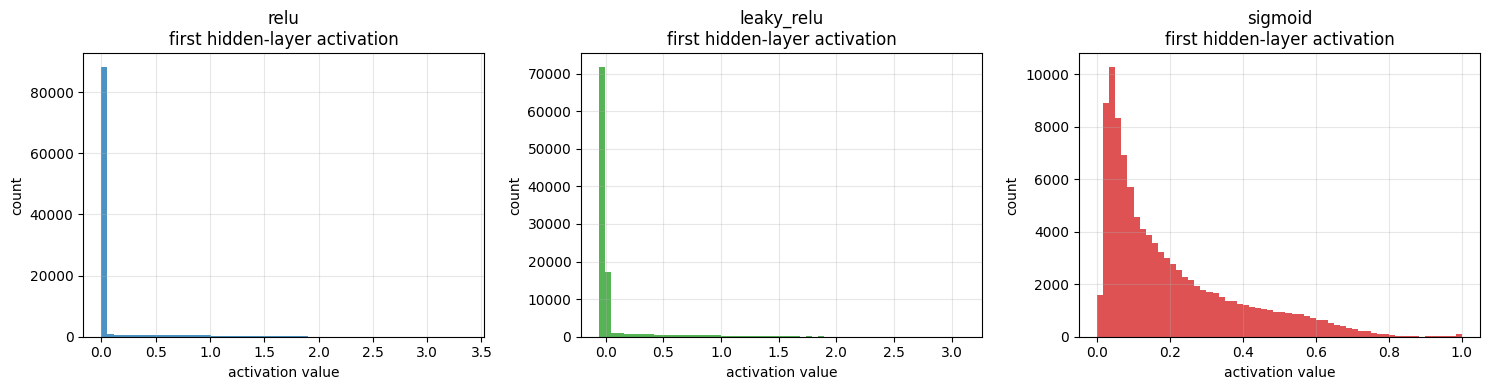

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, act in zip(axes, results):
    names, acts = get_activations(results[act]["model"], x_train)
    first = acts[0].flatten()   # 첫 번째 은닉층 활성화
    ax.hist(first, bins=60, color=colors[act], alpha=0.8)
    ax.set_title(f"{act}\nfirst hidden-layer activation")
    ax.set_xlabel("activation value"); ax.set_ylabel("count")
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### 9-5) Gradient Flow (Vanishing Gradient 확인)
각 Dense 레이어 kernel의 gradient norm을 입력층→출력층 순으로 표시한다.
Sigmoid는 입력층 쪽(dense1)으로 갈수록 gradient norm이 0에 가깝게 작아지는
**vanishing gradient**가 나타난다. ReLU·LeakyReLU는 레이어를 거쳐도 norm이 비슷한 수준으로
유지되어, 세 곡선을 비교하면 Sigmoid만 앞쪽 레이어에서 급격히 낮아지는 형태가 드러난다.


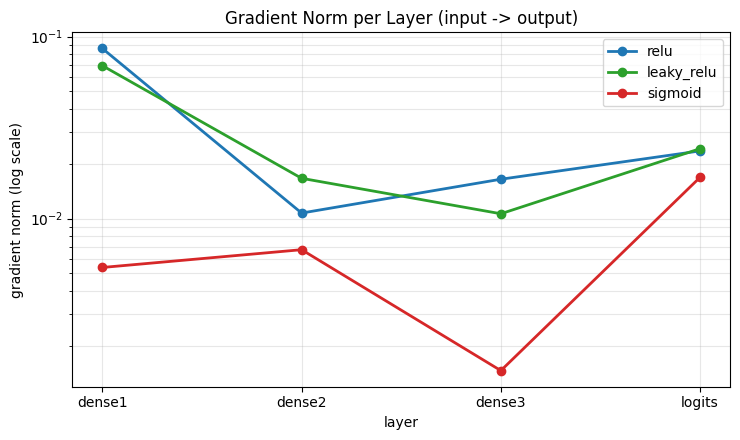

relu       : dense1=0.08599, dense2=0.01072, dense3=0.01645, logits=0.02353
leaky_relu : dense1=0.06916, dense2=0.01664, dense3=0.01063, logits=0.02421
sigmoid    : dense1=0.00539, dense2=0.00675, dense3=0.00146, logits=0.01686


In [27]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# Gradient Flow
# 각 Dense 레이어 kernel의 gradient L2 norm 을 입력층 -> 출력층 순으로 표시한다.
plt.figure(figsize=(7.5, 4.5))
for act in results:
    # Define cce_loss_fn inside the scope where it is used or ensure it's globally available.
    # It's already defined in cbc3ec2a, so it should be fine here.

    # Redefine layer_grad_norms to fix the error
    def layer_grad_norms_fixed(model, X, y_oh):
        # 각 Dense 레이어 kernel의 gradient L2 norm (입력층 -> 출력층 순).
        with tf.GradientTape() as tape:
            logits = model(X, training=True)
            loss = cce_loss_fn(y_oh, logits)

        all_trainable_variables = model.trainable_variables
        all_grads = tape.gradient(loss, all_trainable_variables)

        # Create a mapping from variable object to its gradient
        var_to_grad = {id(var): grad for var, grad in zip(all_trainable_variables, all_grads)}

        norms, names = [], []

        # Iterate through layers to find kernel variables and their names
        for layer in model.layers:
            if layer.trainable_variables:
                for v in layer.trainable_variables:
                    if "kernel" in v.name: # Check if it's a kernel variable
                        # Get the gradient for this kernel variable using the mapping
                        # Use id(v) for comparison to ensure object identity match
                        g = var_to_grad.get(id(v))
                        if g is not None:
                            norms.append(float(tf.norm(g)))
                            names.append(layer.name) # Use the layer's name for the norm
        return names, norms

    names, norms = layer_grad_norms_fixed(results[act]["model"],
                                    x_train, y_train_oh)
    plt.plot(range(len(norms)), norms, "o-", color=colors[act],
             label=act, linewidth=2, markersize=6)
plt.yscale("log")
plt.xticks(range(len(names)), names)
plt.title("Gradient Norm per Layer (input -> output)")
plt.xlabel("layer"); plt.ylabel("gradient norm (log scale)")
plt.legend(); plt.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()

for act in results:
    # Use the fixed function again for printing
    def layer_grad_norms_fixed(model, X, y_oh):
        with tf.GradientTape() as tape:
            logits = model(X, training=True)
            loss = cce_loss_fn(y_oh, logits)

        all_trainable_variables = model.trainable_variables
        all_grads = tape.gradient(loss, all_trainable_variables)

        var_to_grad = {id(var): grad for var, grad in zip(all_trainable_variables, all_grads)}

        norms, names = [], []

        for layer in model.layers:
            if layer.trainable_variables:
                for v in layer.trainable_variables:
                    if "kernel" in v.name:
                        g = var_to_grad.get(id(v))
                        if g is not None:
                            norms.append(float(tf.norm(g)))
                            names.append(layer.name)
        return names, norms

    names, norms = layer_grad_norms_fixed(results[act]["model"],
                                    x_train, y_train_oh)
    print(f"{act:11s}: " + ", ".join(f"{n}={v:.5f}"
                                     for n, v in zip(names, norms)))

### 9-6) 학습된 결정 경계 시각화
2D 입력이므로 각 모델이 학습한 결정 경계를 평면에 직접 그릴 수 있다.
Dead ReLU나 vanishing gradient가 심하면 경계가 단순하거나 데이터를 제대로 분리하지 못한다.

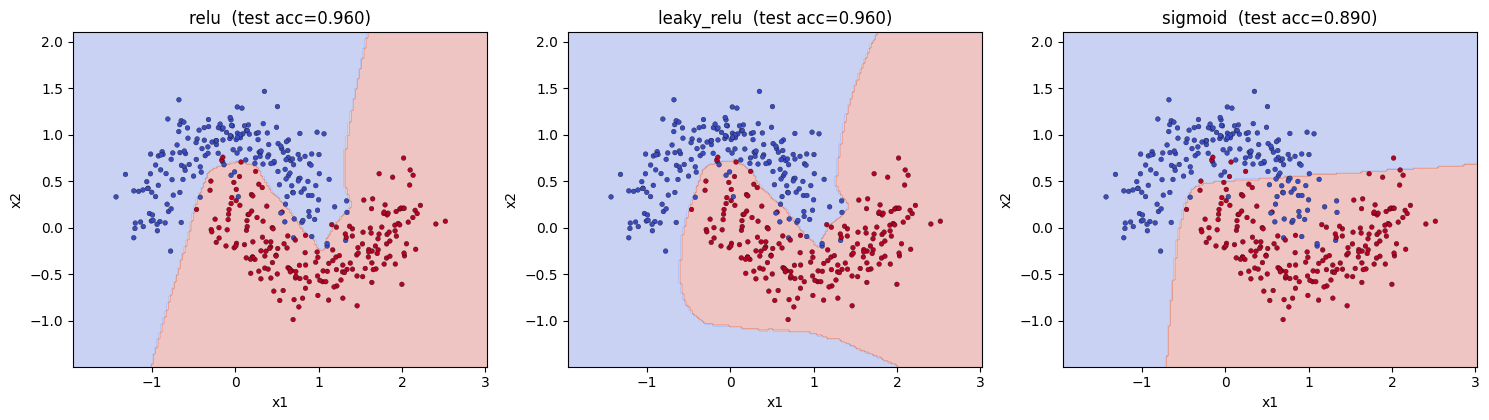

In [28]:
def plot_decision_boundary(model, ax, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    grid = np.c_[xx.ravel(), yy.ravel()].astype("float32")
    logits = model(grid, training=False)
    pred = np.argmax(logits, axis=1).reshape(xx.shape)
    ax.contourf(xx, yy, pred, alpha=0.3, cmap="coolwarm")
    ax.scatter(x_test[:, 0], x_test[:, 1], c=y_test, cmap="coolwarm",
               s=12, edgecolor="k", linewidth=0.2)
    ax.set_title(title)
    ax.set_xlabel("x1"); ax.set_ylabel("x2")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))
for ax, act in zip(axes, results):
    final_acc = results[act]["hist"]["test_acc"][-1]
    plot_decision_boundary(results[act]["model"], ax,
                           f"{act}  (test acc={final_acc:.3f})")
plt.tight_layout()
plt.show()


## 10) 정량적 분석 (표)

수렴 epoch는 test accuracy가 최종 정확도의 99%에 처음 도달한 epoch로 정의한다.

In [29]:
def convergence_epoch(test_acc, ratio=0.99):
    final = test_acc[-1]
    target = final * ratio
    for i, a in enumerate(test_acc):
        if a >= target:
            return i + 1
    return len(test_acc)

rows = []
for act in results:
    h = results[act]["hist"]
    _, ratios = dead_neuron_ratio(results[act]["model"], x_train)
    rows.append({
        "Activation":          act,
        "Dead Neuron Ratio(%)": round(float(np.mean(ratios)) * 100, 2),
        "Final Test Acc(%)":   round(h["test_acc"][-1] * 100, 2),
        "Convergence Epoch":   convergence_epoch(h["test_acc"]),
        "Min Test Loss":       round(min(h["test_loss"]), 4),
    })

try:
    import pandas as pd
    df = pd.DataFrame(rows)
    display(df)
except Exception:
    for r in rows:
        print(r)


,Activation,Dead Neuron Ratio(%),Final Test Acc(%),Convergence Epoch,Min Test Loss
0,relu,40.62,96.0,7,0.0927
1,leaky_relu,0.00,96.0,4,0.0908
2,sigmoid,0.00,89.0,7,0.2346


## 11) 해설 및 분석

### 11-1) 정량 결과 요약
ReLU는 작은 weight 초기화 조건에서 상당 비율의 Dead 뉴런이 발생하지만, make_moons처럼
단순한 문제에서는 살아남은 뉴런만으로도 높은 정확도에 도달할 수 있다. LeakyReLU는 Dead 뉴런이
거의 0%로 ReLU의 문제를 효과적으로 완화한다. Sigmoid는 Dead 뉴런 개념은 없으나
vanishing gradient로 인해 수렴이 느리고 최종 정확도가 가장 낮은 경향을 보인다.

---

### 11-2) 해설질문 답변

**Q1. Dead ReLU 비율이 높으면 학습에 미치는 영향은?**

ReLU 뉴런이 죽으면(=모든 입력에 대해 출력 0) 해당 구간의 gradient도 0이 되어, 역전파 시
그 뉴런의 가중치가 더 이상 갱신되지 않는다. 즉 죽은 뉴런은 학습에서 영구히 배제되어
모델의 유효 표현력(effective capacity)이 감소한다. 특정 레이어에서 Dead 비율이 높으면
그 레이어를 통과하는 정보 경로가 줄어들어, 후속 레이어로 전달되는 특징이 빈약해지고
학습이 정체된다. 9-2의 Dead Neuron Ratio 곡선과 9-3의 레이어별 히트맵에서 죽은 뉴런이
어느 레이어에 집중되는지 확인할 수 있다.

**Q2. LeakyReLU가 Dead ReLU를 얼마나 완화하는가?**

LeakyReLU는 음수 입력에 대해 0이 아니라 작은 기울기(예: 0.01)를 갖는다. 따라서 음수 영역에
들어간 뉴런도 gradient가 0이 아니어서 가중치 갱신이 계속 이루어지고, 다시 양수 영역으로
빠져나올 기회를 얻는다. 그 결과 9-2 곡선과 9-3 레이어별 히트맵에서 LeakyReLU의 Dead 비율은
ReLU보다 현저히 낮게(거의 0에 가깝게) 유지된다. 9-3의 활성화 x 은닉층 히트맵을 보면
ReLU 행에는 진한 칸(높은 dead 비율)이 나타나지만 LeakyReLU 행은 전 레이어가 옅은 색으로
유지되어, 완화 효과가 레이어 단위로 직접 드러난다.

**Q3. Sigmoid의 vanishing gradient는 어디서 발생하는가?**

Sigmoid의 미분은 s(x)(1 - s(x))로, 최댓값이 입력 0에서 0.25에 불과하며 입력이 크거나
작으면 0에 수렴한다. 역전파는 각 층의 미분을 연쇄적으로 곱하므로, 1보다 작은 값(<= 0.25)이
층을 거칠 때마다 곱해져 입력층에 가까울수록 gradient가 기하급수적으로 작아진다.

9-5의 Gradient Flow 그래프에서 이 현상이 직접 관찰된다. Sigmoid 곡선은
출력층 쪽 Dense 레이어에서는 어느 정도 크기를 갖지만, 입력층 방향(dense1)으로 갈수록
norm이 0에 가깝게 주저앉는다. 즉 **vanishing 구간은 출력층에서 입력층으로 가는 앞쪽 레이어
(dense1, dense2 부근)**이며, 이 구간의 가중치는 갱신량이 거의 0이라 학습이 사실상 멈춘다.
반면 ReLU와 LeakyReLU는 레이어를 거쳐도 gradient norm이 비슷한 수준으로 유지되어,
세 곡선을 한 그래프에서 비교하면 Sigmoid만 입력층 쪽으로 급격히 낮아지는 형태가 뚜렷하다.
이것이 9-1 학습 곡선에서 Sigmoid의 loss 감소가 가장 느리고 정확도가 정체되는 직접적 원인이다.

**Q4. 각 Layer가 학습에 기여하는 정도 (히트맵 분석)**

9-3의 레이어별 Dead 뉴런 비율 히트맵에서, 옅은 칸(dead 비율이 낮은 레이어)일수록 살아 있는
뉴런이 많아 다양한 특징을 표현하며 학습에 기여한다. ReLU는 특정 레이어에 진한 칸(높은 dead
비율)이 나타나 그 레이어는 일부 뉴런만 기여하는 반면, LeakyReLU는 모든 레이어가 옅게 유지되어
레이어 전체가 고르게 기여한다. 9-4의 활성화 분포 히스토그램과 함께 보면, ReLU는 0에 큰 막대가
쌓이고(죽은 뉴런 + 음수 차단) LeakyReLU는 0 근처가 덜 뭉치는 차이도 확인된다. 9-5의 레이어별
gradient norm과 종합하면, gradient가 잘 전달되는 레이어가 실제로 활성화도 활발하다는
일관된 패턴을 볼 수 있다.

---

### 11-3) 결론 및 개선 사항

**결론**: 활성화 함수의 선택은 gradient가 네트워크를 통해 흐르는 방식을 결정한다.
ReLU는 계산이 단순하고 양수 구간에서 gradient를 그대로 전달하지만, 작은 초기화나 큰
학습률에서 Dead ReLU에 취약하다. LeakyReLU는 음수 구간의 작은 기울기로 이 문제를
구조적으로 완화한다. Sigmoid는 미분의 상한이 0.25로 작아 깊은 망에서 vanishing gradient를
유발하므로 은닉층 활성화로는 부적합하다.

**개선 방향**:

1. **가중치 초기화 개선 (He / Glorot 초기화)**
   본 실험은 std=0.01의 지나치게 작은 정규분포 초기화로 Dead ReLU를 의도적으로 유도했다.
   실무에서는 ReLU 계열에 He 초기화(`he_normal`, 분산 2/fan_in)를, Sigmoid/Tanh 계열에
   Glorot 초기화(분산 2/(fan_in+fan_out))를 사용한다. 활성화 함수 특성에 맞춰 분산을
   조정하면 초기 가중합이 한쪽으로 치우치지 않아, 학습 시작 단계의 Dead 뉴런 발생을
   크게 줄일 수 있다.

2. **활성화 함수 교체 (LeakyReLU / PReLU / ELU)**
   Dead ReLU가 반복되면 음수 구간에 기울기를 부여하는 변형으로 교체한다. LeakyReLU는
   고정 기울기(0.01)를, PReLU는 그 기울기를 학습 파라미터로 둔다. ELU는 음수 구간을
   부드러운 지수 곡선으로 처리해 출력 평균을 0에 가깝게 만들어 수렴을 돕는다. 본 실험의
   9-3 히트맵에서 확인했듯 LeakyReLU만으로도 Dead 비율이 거의 0으로 떨어진다.

3. **Batch Normalization 도입**
   각 Dense 레이어 뒤에 BatchNorm을 넣으면 레이어 입력 분포를 정규화(평균 0, 분산 1
   부근)하여, 가중합이 ReLU의 음수 영역에 갇히거나 Sigmoid의 포화 영역(출력 0/1 근처)으로
   몰리는 것을 막는다. 이는 Dead ReLU와 vanishing gradient를 동시에 완화하며, 더 큰
   학습률을 안정적으로 쓸 수 있게 해 수렴을 가속한다.

4. **학습률 조정 및 스케줄링**
   학습률이 지나치게 크면 한 번의 큰 갱신으로 뉴런이 음수 영역에 갇혀 Dead ReLU가
   가속된다. 학습률을 낮추거나, 초반에 작게 시작해 점차 키우는 warmup, 후반에 점차
   줄이는 decay 스케줄을 적용하면 갱신이 안정화된다.

5. **활성화 함수의 용도 구분**
   은닉층에는 ReLU 계열을 사용하고, Sigmoid는 vanishing gradient 때문에 깊은 은닉층에는
   부적합하므로 이진 분류의 출력층(확률 변환) 등 제한적 용도로만 사용한다.
